In [3]:
from google.colab import files
uploaded = files.upload()

Saving student_performance_dataset.csv to student_performance_dataset.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("student_performance_dataset.csv")

# First 5 rows
print("First 5 Rows:")
display(df.head())

# Dataset info
print("\nDataset Info:")
df.info()

# Shape
print("\nDataset Shape:")
print(df.shape)

First 5 Rows:


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB

Dataset Shape:
(708, 10)


In [5]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Missing Values:
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

Duplicate Rows:
208

Descriptive Statistics:


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


# Dataset Summary

* Total Records: 708
* Total Columns: 10
* Numerical Features: Study Hours, Attendance Rate, Past Exam Scores, Final Exam Score
* Categorical Features: Gender, Parental Education Level, Internet Access at Home, Extracurricular Activities, Pass/Fail
* Target Variable: Final_Exam_Score

# Data Quality Checks

* Missing Values: 0
* Duplicate Rows: 208
* No missing values were found in the dataset.
* Duplicate records were identified and removed before further analysis.


In [6]:
# Remove duplicate rows
df_cleaned = df.drop_duplicates()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_cleaned.shape)

# Save cleaned dataset
df_cleaned.to_csv("cleaned_student_performance_dataset.csv", index=False)

Original Shape: (708, 10)
Cleaned Shape: (500, 10)


In [7]:
df = df_cleaned.copy()

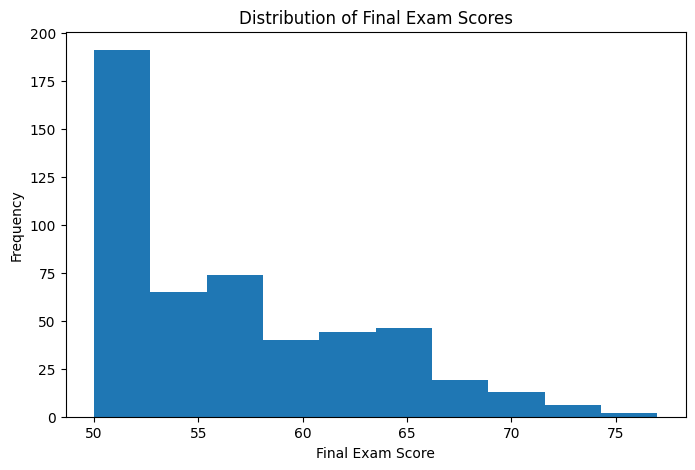

In [9]:
#histogram
plt.figure(figsize=(8,5))
plt.hist(df['Final_Exam_Score'], bins=10)
plt.title('Distribution of Final Exam Scores')
plt.xlabel('Final Exam Score')
plt.ylabel('Frequency')
plt.show()

Observation:
The distribution of final exam scores is slightly right-skewed. Most students scored between 50 and 65 marks, while fewer students achieved scores above 70.


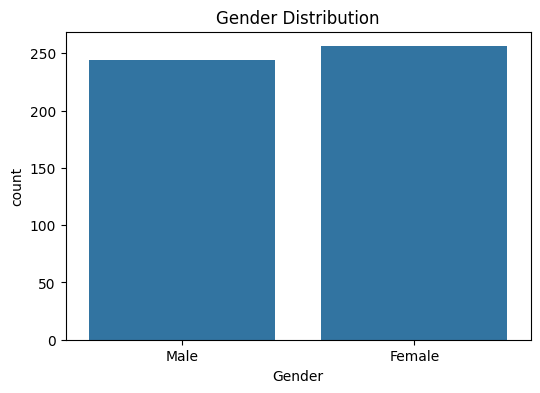

In [10]:
#countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

Observation:
The dataset contains a nearly balanced number of male and female students, indicating that the analysis is not biased toward a particular gender.


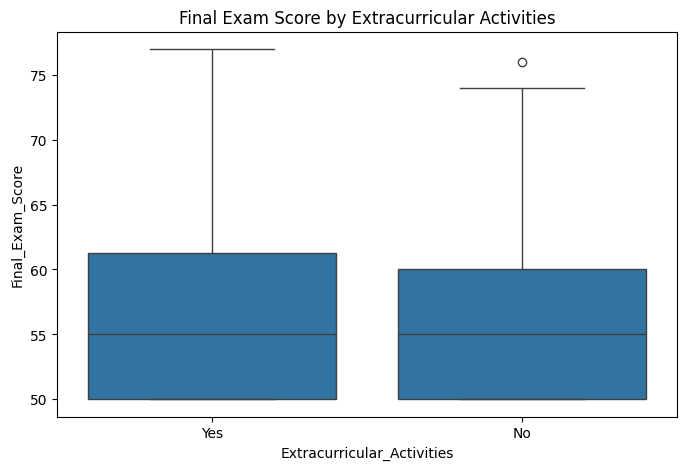

In [11]:
#box plot
plt.figure(figsize=(8,5))
sns.boxplot(x='Extracurricular_Activities',
            y='Final_Exam_Score',
            data=df)
plt.title('Final Exam Score by Extracurricular Activities')
plt.show()

Observation:
Students participating in extracurricular activities and those not participating have similar median scores. However, both groups show some variation in performance, suggesting extracurricular activities alone do not determine academic success.


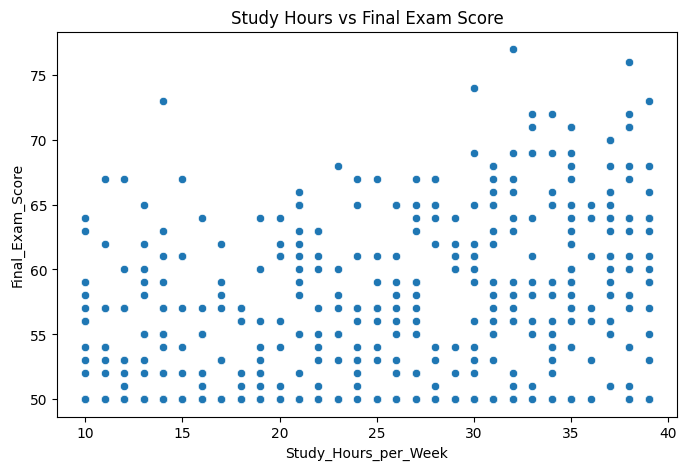

In [12]:
#scatterplot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Study_Hours_per_Week',
                y='Final_Exam_Score',
                data=df)

plt.title('Study Hours vs Final Exam Score')
plt.show()

Observation:
A moderate positive relationship exists between study hours and final exam scores. Students who study more hours per week generally tend to achieve higher scores.



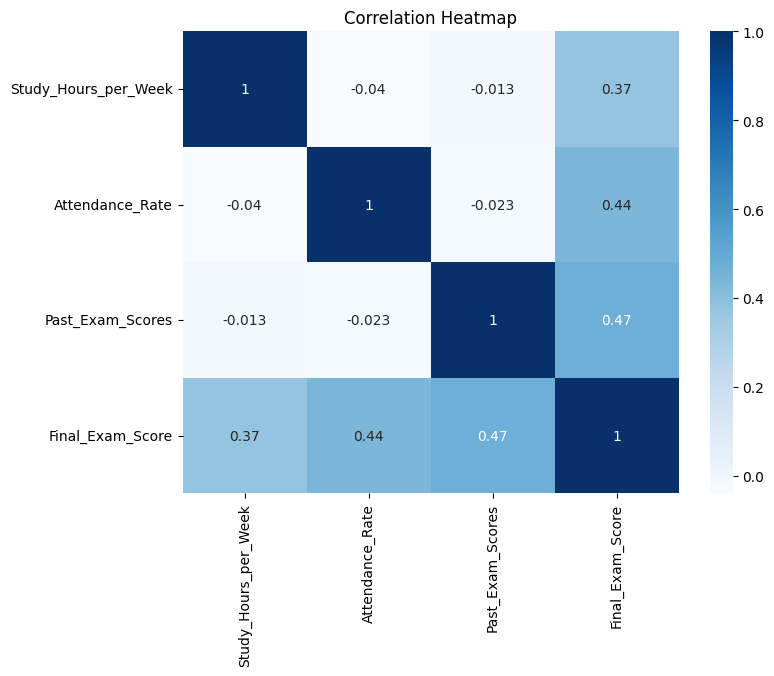

In [13]:
#corelation heatmap
plt.figure(figsize=(8,6))

corr = df[['Study_Hours_per_Week',
           'Attendance_Rate',
           'Past_Exam_Scores',
           'Final_Exam_Score']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='Blues')

plt.title('Correlation Heatmap')
plt.show()

Observation:
Past Exam Scores (0.47) have the strongest positive correlation with Final Exam Scores, followed by Attendance Rate (0.44) and Study Hours per Week (0.37). This suggests that previous academic performance, attendance, and study habits are important factors affecting student success.


# Business Insight Report

## Dataset Overview

The Student Performance Dataset contains 708 student records with information about study habits, attendance, previous exam performance, parental education, internet access, extracurricular activities, and final exam scores.

## Key Findings

1. The dataset contains no missing values, indicating high data quality.

2. A total of 208 duplicate records were identified and removed during the data cleaning process.

3. Most students scored between 50 and 65 marks in the final examination.

4. Students who spend more time studying generally achieve higher final exam scores.

5. Attendance rate shows a positive relationship with academic performance.

6. Past exam scores are the strongest predictor of final exam performance.

7. Gender distribution is balanced, ensuring fair representation of both male and female students.

## Recommendations

1. Encourage students to maintain regular attendance.

2. Promote effective study habits and time management.

3. Identify students with poor past academic performance and provide additional support.

4. Monitor academic progress continuously through periodic assessments.

5. Encourage participation in extracurricular activities while maintaining academic focus.

## Conclusion

The analysis indicates that study hours, attendance rate, and previous academic performance significantly influence final exam scores. Educational institutions can improve student outcomes by focusing on attendance monitoring, academic support programs, and effective study planning.
